## P(X) integration test


In this notebook we will integrate the density probability function $P(\widetilde{X})$ using two approach: 

1. Integrate in a hypervolume of 6 variables 

2. Integrate the positions ($x$,$y$,$z$) in a sphere and the velocities ($v_x$,$v_y$,$v_z$) in a cube

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    trasformation_E_to_X, 
    computeNumericalJacobian,
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

### Veryfing CMND fit 

C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\jacobian_calculations\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


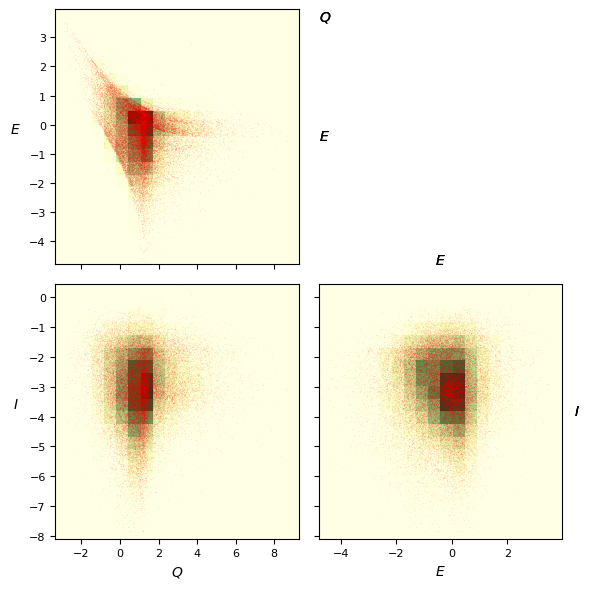

In [3]:
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [4]:
def P_E_CMND(q: float, e: float, i: float, F: mm.FitCMND) -> float:
    max = 2*np.pi; min = 0

    element = np.array([q, e, i])
    scales=[1.35,1.00,np.pi]
    u_element = mm.Util.tIF(element, scales, mm.Util.f2u)

    P_qei = F.cmnd.pdf(u_element)
    P_WwM = 1/(max - min)**3

    return P_qei * P_WwM

In [5]:
def Jacobian_qei_to_QEI(q: float, e: float, i: float, q_max: float, e_max: float, i_max: float) -> np.array:
    partialA_a = q_max/(q*(q_max - q))
    partialA_e = 0
    partialA_i = 0
    partialE_a = 0
    partialE_e = e_max/(e*(e_max - e))
    partialE_i = 0
    partialI_a = 0
    partialI_e = 0
    partialI_i = i_max/(i*(i_max - i))

    Jacobian = np.array([
        [partialA_a, partialA_e, partialA_i], 
        [partialE_a, partialE_e, partialE_i], 
        [partialI_a, partialI_e, partialI_i]
        ])
        
    return Jacobian

In [6]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        print('evaluating state vector: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        print('Orbital elements ', q, e, i, Omega, w, M, a)
        if q > 1.35 or e > 1: 
            print("--------------NO SENSE ORBIT-----------------")
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    print("------------PROBLEMATIC POINT------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('--------------Nan value encounter-----------')
                        print(P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    
    return P.reshape(shape), neas_number, not_neas_number

### Integration in hypercube 

In [7]:
def hypercube_surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf, neas_number, not_neas_number = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral, neas_number, not_neas_number

In [9]:
q_max, e_max, i_max =  (1.35, 1.0, np.pi)
x, y, z, vx, vy, vz = (1.0466234757101576, 0.5466234757101576, 0.466234757101576, 0.49175300704240293, 6.775775737844404, 0.49175300704240293)
elements  = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)

q = elements[0]
e = elements[1]
i = elements[2]
Omega = elements[3]
w = elements[4]
M = elements[5]
a = q/(1-e)
print('------------- orbital elements: ------------')
print(q, e, i, Omega, w, M, a)

print('------------- Jacobians: ------------')
J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i, q_max,e_max,i_max)
print('Jacobian coordinate trasformation: ')
print(J)
print('Jaccobian bounded trasformation: ')
print(J_qei_to_QEI)

print('------------- Determinantes: ------------')
det = np.linalg.det(J)
inv_det = 1.0/det 
det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
print('inverse determinant Jacobian coordinate trasformation: ', abs(det))
print('determinant Jaccobian bounded trasformation: ', abs(det_QEI))

print('Probability Calculation')
P = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
print('P = ', P)

------------- orbital elements: ------------
0.8363132560107014 0.6650051644067845 0.4024453927778762 4.810816748402446 0.5010826451283568 0.29113221609418904 2.4964959669594347
------------- Jacobians: ------------
Jacobian coordinate trasformation: 
[[  1.25147302   0.88709633  -0.46397813  -0.54662348  -0.5208964
    0.30867793]
 [  0.65361092   5.7327375   -0.04581638   1.04662348   1.1447306
    4.25321737]
 [  0.55748818   0.61559639   1.09527381   0.          -0.17277609
    0.30867793]
 [ -0.29400049 -12.451743    -0.48937287  -6.77577574  -6.25335869
  -12.68065116]
 [ -4.05097952  -7.59507398  -0.04832404   0.49175301   0.64413732
   -6.62276528]
 [ -0.29400049  -5.59249683   1.15522101   0.          -2.62209288
   -5.64879391]]
Jaccobian bounded trasformation: 
[[3.14243591 0.         0.        ]
 [0.         4.48886837 0.        ]
 [0.         0.         2.84988629]]
------------- Determinantes: ------------
inverse determinant Jacobian coordinate trasformation:  152.424709

In [10]:
q_max, e_max, i_max =  (1.35, 1.0, np.pi)
x, y, z, vx, vy, vz = (-1.0466234757101576, 0.5466234757101576, 0.466234757101576, 0.49175300704240293, 6.775775737844404, 0.49175300704240293)
elements  = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)

q = elements[0]
e = elements[1]
i = elements[2]
Omega = elements[3]
w = elements[4]
M = elements[5]
a = q/(1-e)
print('------------- orbital elements: ------------')
print(q, e, i, Omega, w, M, a)

print('------------- Jacobians: ------------')
J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i, q_max,e_max,i_max)
print('Jacobian coordinate trasformation: ')
print(J)
print('Jaccobian bounded trasformation: ')
print(J_qei_to_QEI)

print('------------- Determinantes: ------------')
det = np.linalg.det(J)
inv_det = 1.0/det 
det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
print('inverse determinant Jacobian coordinate trasformation: ', abs(det))
print('determinant Jaccobian bounded trasformation: ', abs(det_QEI))

print('Probability Calculation')
P = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
print('P = ', P)

------------- orbital elements: ------------
0.9983947434469251 0.6000815716666655 2.756373762537863 4.460461147764972 0.6582486178415297 0.2667684107272321 2.4964959669594347
------------- Jacobians: ------------
Jacobian coordinate trasformation: 
[[-1.04830628  0.02185976 -0.45151744 -0.54662348  0.55023551  0.30867793]
 [ 0.54750236  4.53391906  0.11621899 -1.04662348  1.13958603  4.25321737]
 [ 0.46698439  0.44967655 -1.14984301  0.         -0.10088281  0.30867793]
 [-0.24627183 10.13140193 -0.47623017 -6.77577574  6.32528206 12.68065116]
 [-3.39333504 -5.08251345  0.12257996  0.49175301 -0.27676628 -6.62276528]
 [-0.24627183 -4.4920821  -1.21277693  0.         -2.51176953 -5.64879391]]
Jaccobian bounded trasformation: 
[[3.84570639 0.         0.        ]
 [0.         4.16695004 0.        ]
 [0.         0.         2.95872219]]
------------- Determinantes: ------------
inverse determinant Jacobian coordinate trasformation:  110.53515059948364
determinant Jaccobian bounded trasforma